## Logistic Regression with Adagrad Optimisation

In [34]:
library(numDeriv)
library(nloptr)
library(httpgd)
set.seed(2023)

We model a binary classification problem where the target variable is $y \in \{0, 1\}$. 
The probability that $y=1$ given an input $x$ is modeled using the Sigmoid function:$$h_w(x) = \sigma(w_0 + w_1 x) = \frac{1}{1 + e^{-(w_0 + w_1 x)}}$$where $w = [w_0, w_1]^T$ are the weights. 

In [35]:
data_generating_model <- function(n, w) {
  z <- rep(NaN, times = n * 2)
  z <- matrix(z, nrow = n, ncol = 2)
  z[, 1] <- runif(n, min = -10, max = 10) # x values
  p <- w[1] + w[2] * z[, 1]
  p <- exp(p) / (1 + exp(p))
  z[, 2] <- rbinom(n, size = 1, prob = p) # y values
  return(z)
}

In [36]:
prediction_rule <- function(x, w) {
  h <- exp(w[1] + w[2] * x) / (1.0 + exp(w[1] + w[2] * x))
  return(h)
}

To evaluate the performance we use the Log-Loss. For a single observation $(x_i, y_i)$, the loss is defined as: $$\ell(w; x_i, y_i) = - \left[ y_i \log(h_w(x_i)) + (1 - y_i) \log(1 - h_w(x_i)) \right]$$
 
 The Empirical Risk (objective function to minimise) is the average loss across a batch of $n$ samples: $$R(w) = \frac{1}{n} \sum_{i=1}^{n} \ell(w|x_i, y_i)$$

In [37]:
loss_fun <- function(w, z) {
  epsilon <- 1e-15
  x <- z[, 1]
  y <- z[, 2]
  h <- prediction_rule(x, w)
  ell <- -y * log(h + epsilon) - (1 - y) * log(1 - h + epsilon)
  return(ell)
}

We take the gradient of the risk wrt the weights. The partial derivatives of the risk function are:$$\nabla_w R(w) = \frac{1}{n} \sum_{i=1}^{n} (h_w(x_i) - y_i) \left( \begin{matrix} 1 \\ x_i \end{matrix}\right)$$

In [38]:
grad_risk_fun <- function(w, z) {
  x <- z[, 1]
  y <- z[, 2]
  h <- prediction_rule(x, w)
  grad_w0 <- mean(h - y)
  grad_w1 <- mean((h - y) * x)
  return(c(grad_w0, grad_w1))
}

Instead of standard SGD which uses a fixed global learning rate, we use AdaGrad, which adapts the learning rate for each parameter individually by scaling it inversely proportional to the square root of the sum of all its historical squared gradients. For each iteration $t$, it calculates the gradient $g_t$ on a mini-batch, then $$G_t = G_{t-1} + g_t \odot g_t$$Update the weights:$$w_{t+1} = w_t - \frac{\eta}{\sqrt{G_t + \varepsilon}} \odot g_t,$$ where $\eta$ is the base learning rate, $\varepsilon \ll 1$ is a smoothing term and $\odot$ represents element-wise multiplication.

In [52]:
adagrad <- function(z, w_seed, m = 1, eta = 1, Tmax = 500, eps = 1e-6) {
  n_obs <- nrow(z)
  w <- w_seed
  w_chain <- matrix(NA, nrow = Tmax, ncol = length(w))
  G <- rep(0.0, times = length(w))

  for (t in 1:Tmax) {
    J <- sample.int(n = n_obs, size = m, replace = TRUE)
    z_batch <- z[J, , drop = FALSE]
    g <- grad_risk_fun(w, z_batch)
    G <- G + g**2
    w <- w - eta * (1 / sqrt(G + eps)) * g

    w_chain[t, ] <- w
  }
  return(w_chain)
}

In [53]:
n_obs <- 10000
w_true <- c(0, 1)
z_obs <- data_generating_model(n = n_obs, w = w_true)
w_glm <- as.numeric(glm(z_obs[, 2] ~ 1 + z_obs[, 1], family = "binomial")$coefficients)
cat("GLM weights: w0 =", w_glm[1], ", w1 =", w_glm[2], "\n")

GLM weights: w0 = -0.0441444 , w1 = 0.9818653 


In [54]:
w_chain_sgd <- adagrad(z_obs, w_seed = c(-0.3, 3.0), m = 1, Tmax = 500)
w_chain_batch <- adagrad(z_obs, w_seed = c(-0.3, 3.0), m = 100, Tmax = 500)

integer(0)

integer(0)

integer(0)

integer(0)

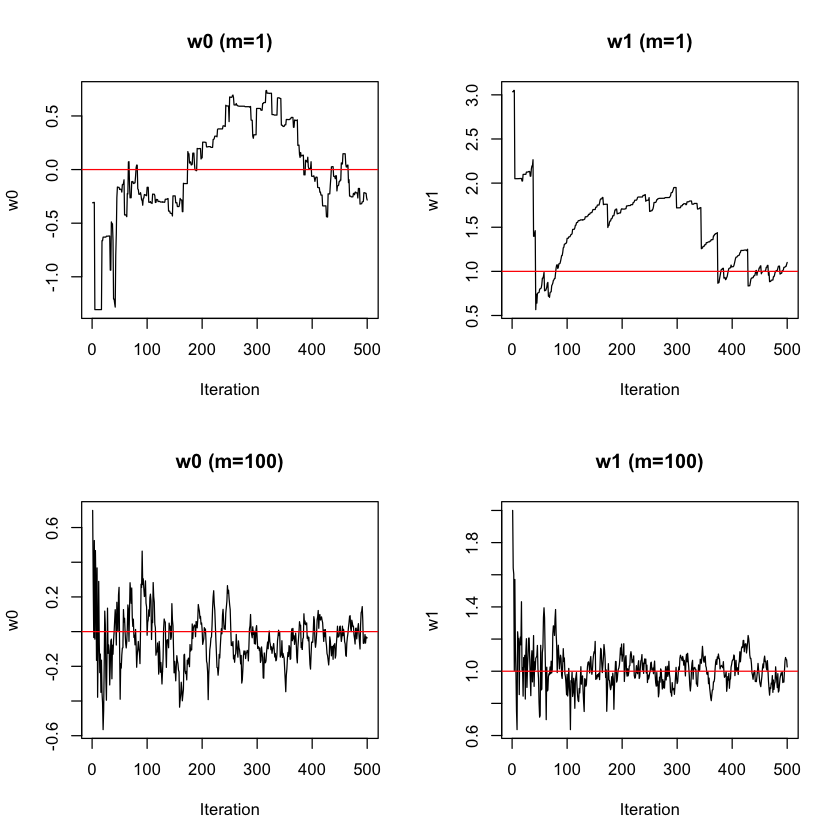

In [55]:
par(mfrow = c(2, 2))
plot(w_chain_sgd[, 1], type = "l", main = "w0 (m=1)", xlab = "Iteration", ylab = "w0") +
  abline(h = w_true[1], col = "red")

plot(w_chain_sgd[, 2], type = "l", main = "w1 (m=1)", xlab = "Iteration", ylab = "w1") +
  abline(h = w_true[2], col = "red")

plot(w_chain_batch[, 1], type = "l", main = "w0 (m=100)", xlab = "Iteration", ylab = "w0") +
  abline(h = w_true[1], col = "red")

plot(w_chain_batch[, 2], type = "l", main = "w1 (m=100)", xlab = "Iteration", ylab = "w1") +
  abline(h = w_true[2], col = "red")

* $m=1$ case shows erratic, high variance
* $m=100$ (batch) case shows faster and tighter convergence
* Adagrad element - amplitude of lines decreases with more iterations, learning rate shrinks as model reaches minimum to prevent overshooting.
* w0 has smaller gradients than w1, hence G grows slower, so less influence of adagrad. Standardize inputs below to combat this. 

In [59]:
z_obs[, 1] <- scale(z_obs[, 1])

w_glm_scaled <- as.numeric(glm(z_obs[, 2] ~ 1 + z_obs[, 1], family = "binomial")$coefficients)
cat("New Target Weights: w0 =", w_glm_scaled[1], "| w1 =", w_glm_scaled[2], "\n")



New Target Weights: w0 = 0.08164225 | w1 = 5.675738 


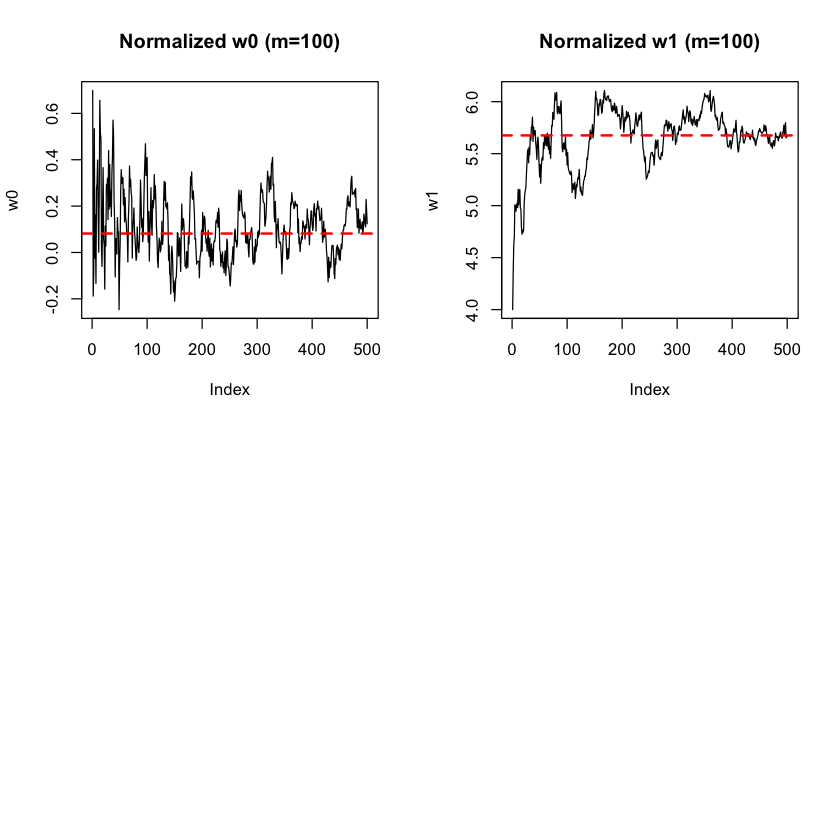

In [60]:

w_chain_scaled <- adagrad(z_obs, w_seed = c(-0.3, 3.0), m = 100, Tmax = 500)

par(mfrow=c(2,2)) 
plot(w_chain_scaled[,1], type='l', main="Normalized w0 (m=100)", ylab="w0")
abline(h=w_glm_scaled[1], col='red', lwd=2, lty=2)

plot(w_chain_scaled[,2], type='l', main="Normalized w1 (m=100)", ylab="w1")
abline(h=w_glm_scaled[2], col='red', lwd=2, lty=2)

More even variance in both due to standardisation.

### Hyperparameters
* Learning rate ($\eta$ ) - controls step size. 
    * If base rate large, results in rapid convergence but high volatility. 
    * If base rate too small, effective learning rate approaches 0, parameter updates are negligible. 
* Batch size (m) - observations per step
    * SGD (m=1) results in instability
    * Larger batch (m=100) means noise averages out, more stable. Computationally slower.
* Tmax - max number of iterations. Smaller $eta$ should be accounted for by larger Tmax to give more time to converge. 
